# INSTALACIÓN DE BIBLIOTECAS

In [ ]:
pip install opencv-python scikit-image matplotlib

     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ---------------------------------------- 60.8/60.8 kB 3.2 MB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/109.0 kB ? eta -:--:--
     -------------------------------------- 109.0/109.0 kB 6.2 MB/s eta 0:00:00
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
    --------------------------------------- 0.6/39.0 MB 33.9 MB/s eta 0:00:02
   - -------------------------------------- 1.1/39.0 MB 17.6 MB/s eta 0:00:03
   - -------------------------------------- 1.9/39.0 MB 20.6 MB/s eta 0:00:02
   -- ------------------------------------- 2.5/39.0 MB 19.7 MB/s eta 0:00:02
   --- ------------------------------------ 3.2/39.0 MB 18.3 MB/s eta 0:00:02
   --- ------------------------------------ 3.8/39.0 MB 18.6 MB/s eta 0:00:02
   ---- -------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# OPERACIONES BÁSICAS CON IMÁGENES

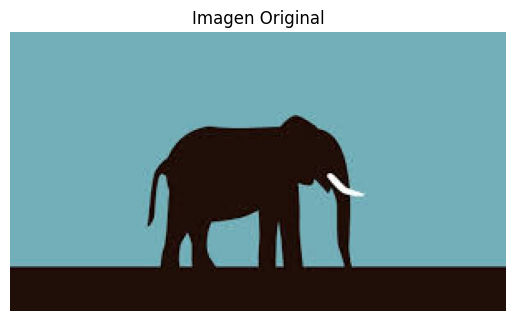

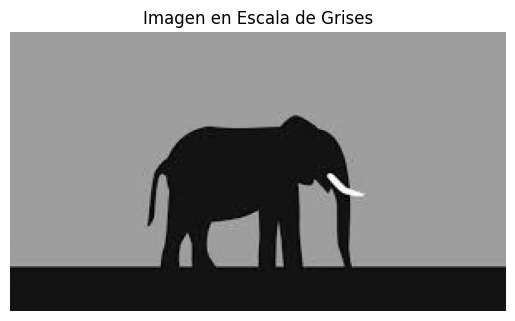

✅ Imagen en escala de grises guardada como 'imagen_gris.jpg'


In [ ]:
import cv2
from skimage import io 
import matplotlib.pyplot as plt

# Leer una imagen
imagen = cv2.imread('imagen_ejemplo.jpeg')

if imagen is None:
    print("⚠️ No se pudo cargar la imagen. Verifica la ruta.")
else:
    # Convertir de BGR (formato de OpenCV) a RGB (para mostrar bien los colores)
    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen original
    plt.imshow(imagen_rgb)
    plt.title("Imagen Original")
    plt.axis("off")
    plt.show()

    # Convertir la imagen a escala de grises
    imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

    # Mostrar imagen en escala de grises
    plt.imshow(imagen_gris, cmap="gray")
    plt.title("Imagen en Escala de Grises")
    plt.axis("off")
    plt.show()

    # Guardar imagen procesada en disco
    cv2.imwrite("imagen_gris.jpg", imagen_gris)
    print("✅ Imagen en escala de grises guardada como 'imagen_gris.jpg'")


# TRANSFORMACIONES GEOMÉTRICAS

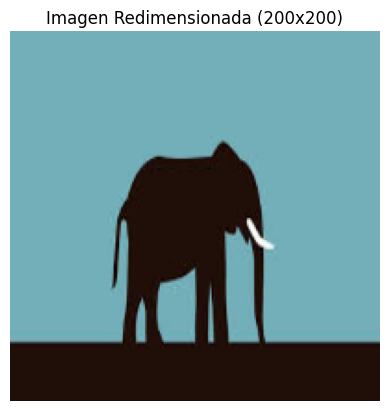

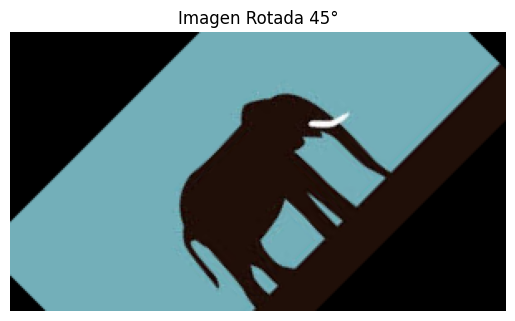

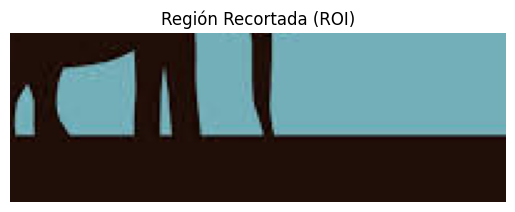

In [ ]:
# Redimensionar a 200x200
imagen_redimensionada = cv2.resize(imagen, (200, 200))

# Mostrar imagen redimensionada
imagen_rgb = cv2.cvtColor(imagen_redimensionada, cv2.COLOR_BGR2RGB)
plt.imshow(imagen_rgb)
plt.title("Imagen Redimensionada (200x200)")
plt.axis("off")
plt.show()

# Rotar 45 grados y obtener dimensiones
(h, w) = imagen.shape[:2]
centro = (w // 2, h // 2)

# Crear matriz de rotación
matriz_rotacion = cv2.getRotationMatrix2D(centro, 45, 1.0)

# Aplicar rotación
imagen_rotada = cv2.warpAffine(imagen, matriz_rotacion, (w, h))

# Mostrar imagen rotada
imagen_rgb_rotada = cv2.cvtColor(imagen_rotada, cv2.COLOR_BGR2RGB)
plt.imshow(imagen_rgb_rotada)
plt.title("Imagen Rotada 45°")
plt.axis("off")
plt.show()

# Recortar región de interés (ROI)

roi = imagen[100:300, 100:300]

# Mostrar la imagen recortada
if roi.size > 0:
    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
    plt.imshow(roi_rgb)
    plt.title("Región Recortada (ROI)")
    plt.axis("off")
    plt.show()
else:
    print("⚠️ La región seleccionada está fuera de los límites de la imagen original.")


# FILTROS Y DETECCIÓN DE BORDES

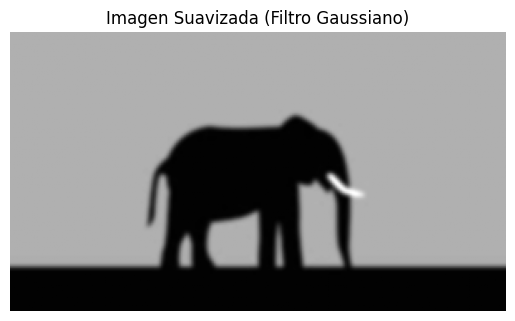

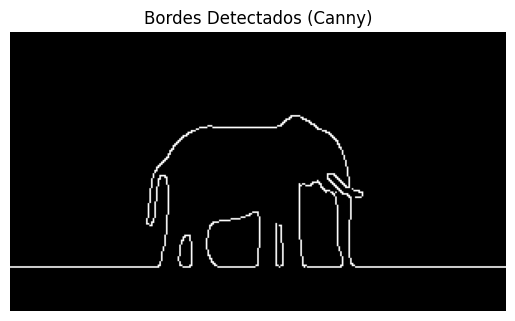

In [ ]:
# Suavizado con filtro gaussiano
imagen_suavizada = cv2.GaussianBlur(imagen_gris, (7, 7), 0)

# Mostrar imagen suavizada
plt.imshow(imagen_suavizada, cmap="gray")
plt.title("Imagen Suavizada (Filtro Gaussiano)")
plt.axis("off")
plt.show()

# Detección de bordes con canny
bordes = cv2.Canny(imagen_suavizada, 50, 150)

# Mostrar bordes detectados
plt.imshow(bordes, cmap="gray")
plt.title("Bordes Detectados (Canny)")
plt.axis("off")
plt.show()

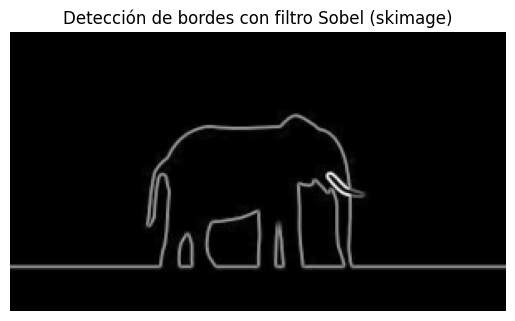

In [42]:
from skimage import filters

# Aplicar filtro Sobel en imagen en escala de grises
sobel = filters.sobel(imagen_gris)

# Mostrar resultado del filtro Sobel
plt.imshow(sobel, cmap='gray')
plt.title("Detección de bordes con filtro Sobel (skimage)")
plt.axis("off")
plt.show()


# DETECCIÓN DE ROSTROS CON HAAR CASCADES

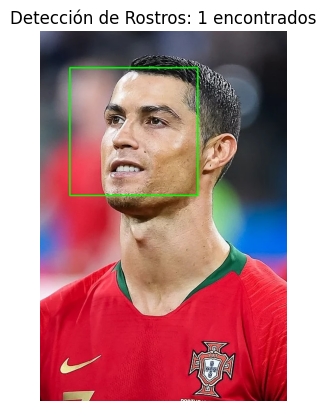

In [ ]:
# Cargar el clasificador preentrenado de rostros (incluido en OpenCV)
clasificador_rostros = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

imagen_rostro = cv2.imread("Cr7.jpg")

if imagen_rostro is None:
    print("⚠️ No se pudo cargar la imagen.")
else:
    # Convertir a escala de grises
    gris = cv2.cvtColor(imagen_rostro, cv2.COLOR_BGR2GRAY)

    # Detectar rostros
    rostros = clasificador_rostros.detectMultiScale(gris, scaleFactor=1.1, minNeighbors=5)

    # Dibujar rectángulos si hay detecciones
    for (x, y, w, h) in rostros:
        cv2.rectangle(imagen_rostro, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # Mostrar imagen con detecciones (si las hay)
    imagen_rgb = cv2.cvtColor(imagen_rostro, cv2.COLOR_BGR2RGB)
    plt.imshow(imagen_rgb)
    plt.title(f"Detección de Rostros: {len(rostros)} encontrados")
    plt.axis("off")
    plt.show()


# SEGMENTACIÓN DE IMÁGENES

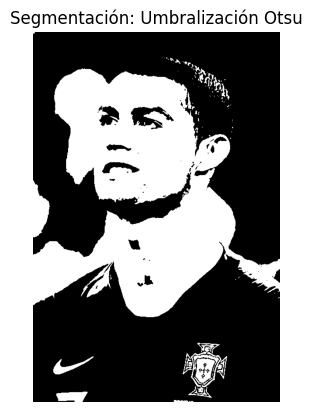

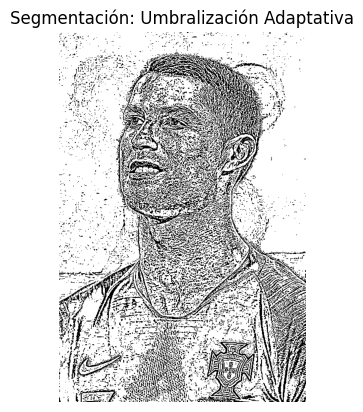

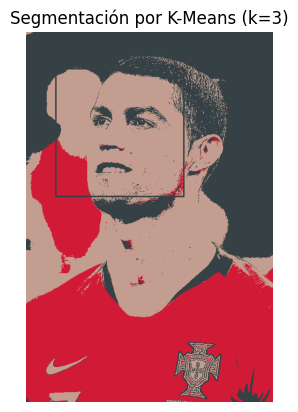

In [ ]:
import numpy as np

# Umbralización global (OTSU)
blur = cv2.GaussianBlur(gris, (5, 5), 0)
_, otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(otsu, cmap="gray")
plt.title("Segmentación: Umbralización Otsu")
plt.axis("off")
plt.show()

# Umbralización adaptativa
adaptativa = cv2.adaptiveThreshold(gris, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

plt.imshow(adaptativa, cmap="gray")
plt.title("Segmentación: Umbralización Adaptativa")
plt.axis("off")
plt.show()

# Segmentación con K-Means
# Convertir imagen de BGR a RGB para visualización
imagen_rgb = cv2.cvtColor(imagen_rostro, cv2.COLOR_BGR2RGB)

# Redimensionar a matriz 2D de píxeles (para clustering)
pixel_vals = imagen_rgb.reshape((-1, 3))
pixel_vals = np.float32(pixel_vals)

# Definir criterios y aplicar KMeans
criterios = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
k = 3  # número de clústeres
_, etiquetas, centros = cv2.kmeans(pixel_vals, k, None, criterios, 10, cv2.KMEANS_RANDOM_CENTERS)

# Convertir centros a enteros
centros = np.uint8(centros)

# Mapear etiquetas a colores
segmentos = centros[etiquetas.flatten()]
imagen_segmentada = segmentos.reshape(imagen_rgb.shape)

plt.imshow(imagen_segmentada)
plt.title("Segmentación por K-Means (k=3)")
plt.axis("off")
plt.show()


# CONCLUSIÓN

Se aplicaron diversas técnicas de procesamiento de imágenes con OpenCV y Scikit-Image. Primero se realizaron transformaciones geométricas: redimensionamiento, rotación de 45° y recorte (ROI). Estas operaciones permitieron observar cómo se alteran las dimensiones y el contenido espacial de una imagen.

Luego, se aplicó un filtro Gaussiano para suavizar y se utilizaron dos métodos de detección de bordes: Canny (OpenCV) y Sobel (Scikit-Image). El detector de Canny proporcionó bordes más definidos y precisos, especialmente en los contornos del elefante, siendo ideal para segmentaciones más nítidas. En cambio, el filtro de Sobel ofreció una detección más suave y continua, útil en contextos menos exigentes o como paso previo a otros análisis.

En la imagen del rostro, se probó detección facial mediante Haar Cascades, identificando correctamente una cara en la fotografía.

En la etapa de segmentación, se compararon tres métodos:
– Umbralización de Otsu mostró buenos resultados con fondos simples.
– Umbralización adaptativa ofreció más detalle, aunque con algo de ruido.
– K-Means (k=3) fue el método más efectivo para dividir la imagen en regiones visuales coherentes (por color).

Se aplicaron las mismas técnicas sobre una imagen ilustrada y una fotografía real para observar diferencias de comportamiento.

Como conclusión, todas las técnicas funcionaron correctamente y permitieron visualizar de forma clara el poder del preprocesamiento en visión por computador. La experiencia fue útil para comparar métodos y entender sus aplicaciones según el tipo de imagen y los objetivos del análisis.